In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, make_scorer, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display, Markdown
from sklearn.neighbors import KNeighborsClassifier


In [34]:
df = pd.read_csv('train-2.csv', index_col='id')

In [35]:
class DataPreprocessor:
    """
    A class to preprocess data for machine learning models.
    """

    def __init__(self, df):
        """
        Make a copy of the input dataframe.

        Parameters
        ----------
        df : pandas.DataFrame
            The dataframe to preprocess.
        """
        self.df = df.copy()
    
    def age_to_int(self):
        """
        Converts the 'age' column to integer.
        """
        self.df['age'] = self.df['age'].astype(int)
        return self.df

    def drop_not_needed_columns(self):
        self.df = self.df[self.df['gender_Other'] == 0]
        self.df.drop(['gender_Other', 'work_type_Never_worked', 'work_type_children'], axis=1, inplace=True)
        return self.df


    def preprocess_gender(self):
        """
        Processes gender columns.

        Converts 'gender_Female' and 'gender_Male' columns into a single
        'gender' column with binary values: 0 for Female and 1 for Male.
        Filters out rows where 'gender_Other' is 1.
        """
        self.df['gender'] = self.df.apply(
            lambda row: 0 if row['gender_Female'] else 1,
            axis=1
        )
        self.df.drop(['gender_Female', 'gender_Male'], axis=1, inplace=True)
        return self.df
    
    def preprocess_ever_married(self):
        """
        Converts 'ever_married' columns to a single 'ever_married' column.

        The new column has binary values: 1 for Yes and 0 for No.
        """
        self.df['ever_married'] = self.df.apply(
            lambda row: 1 if row['ever_married_Yes'] else 0,
            axis=1
        )
        self.df.drop(['ever_married_No', 'ever_married_Yes'], axis=1, inplace=True)
        return self.df
    
    def preprocess_residence_type(self):
        """
        Converts residence type columns to a single 'residence_type' column.

        The new column has binary values: 0 for Rural and 1 for Urban.
        """
        self.df['residence_type'] = self.df.apply(
            lambda row: 0 if row['Residence_type_Rural'] else 1,
            axis=1
        )
        self.df.drop(['Residence_type_Rural', 'Residence_type_Urban'], axis=1, inplace=True)
        return self.df
    
    def preprocess_work_type(self):
        """
        Converts work type columns and creates a 'work_type_self_employed' column.

        The new column has binary values: 1 if self-employed, else 0.
        """
        self.df['work_type_self_employed'] = self.df.apply(
            lambda row: 1 if row['work_type_Self-employed'] else 0,
            axis=1
        )
        self.df.drop(['work_type_Govt_job', 'work_type_Private',
                      'work_type_Self-employed'], axis=1, inplace=True)
        return self.df
    
    def convert_bool_to_int(self):
        """
        Converts boolean columns to integer type.
        """
        self.df[self.df.select_dtypes(include='bool').columns] = self.df.select_dtypes(include='bool').astype(int)
        return self.df
    
    def drop_columns(self, columns):
        """
        Drops specified columns from the dataframe.

        Parameters
        ----------
        columns : list of str
            List of column names to be dropped.
        """
        self.df.drop(columns=columns, inplace=True)
        return self.df
    
    def add_age_above_60(self):
        """
        Adds a binary 'age_above_60' column.

        The new column has values of 1 if age > 60, else 0.
        """
        self.df['age_above_60'] = self.df['age'].apply(lambda x: 1 if x > 60 else 0)
        return self.df
    
    def add_interaction_terms(self):
        """
        Creates interaction terms based on existing features.

        New columns include:
        - 'age_above_60_hypertension': Product of 'age_above_60' and 'hypertension'
        - 'age_above_60_heart_disease': Product of 'age_above_60' and 'heart_disease'
        - 'hypertension_former_smoker': Product of 'hypertension' and 'smoking_status_formerly smoked'
        """
        self.df['age_above_60_hypertension'] = self.df['age_above_60'] * self.df['hypertension']
        self.df['age_above_60_heart_disease'] = self.df['age_above_60'] * self.df['heart_disease']
        self.df['hypertension_former_smoker'] = self.df['hypertension'] * self.df['smoking_status_formerly smoked']
        return self.df
    
    def categorize_bmi(self):
        """
        Categorizes BMI into 'underweight', 'normal', 'overweight', and 'obese'.

        Creates a new 'bmi_category' column based on the following thresholds:
        - BMI < 18.5: 'underweight'
        - 18.5 <= BMI < 24.9: 'normal'
        - 24.9 <= BMI < 29.9: 'overweight'
        - BMI >= 30: 'obese'
        """
        def categorize(bmi):
            if bmi < 18.5:
                return 'underweight'
            elif 18.5 <= bmi < 24.9:
                return 'normal'
            elif 24.9 <= bmi < 29.9:
                return 'overweight'
            else:
                return 'obese'
        self.df['bmi_category'] = self.df['bmi'].apply(categorize)
        return self.df
    
    def categorize_glucose(self):
        """
        Categorizes glucose levels into 'normal', 'prediabetic', and 'diabetic'.

        Creates a new 'glucose_category' column based on the following thresholds:
        - avg_glucose_level < 140: 'normal'
        - 140 <= avg_glucose_level < 200: 'prediabetic'
        - avg_glucose_level >= 200: 'diabetic'
        """
        def categorize(avg_glucose_level):
            if avg_glucose_level < 140:
                return 'normal'
            elif 140 <= avg_glucose_level < 200:
                return 'prediabetic'
            else:
                return 'diabetic'
        self.df['glucose_category'] = self.df['avg_glucose_level'].apply(categorize)
        return self.df
    
    def encode_categories(self):
        """
        Encodes categorical features for BMI and glucose categories.

        Creates two new columns:
        - 'glucose_category_encoded' with values 0 for 'normal', 1 for 'prediabetic', and 2 for 'diabetic'.
        - 'bmi_category_encoded' with values 0 for 'underweight', 1 for 'normal', 2 for 'overweight', and 3 for 'obese'.
        """
        glucose_mapping = {'normal': 0, 'prediabetic': 1, 'diabetic': 2}
        self.df['glucose_category_encoded'] = self.df['glucose_category'].map(glucose_mapping)
        
        bmi_mapping = {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}
        self.df['bmi_category_encoded'] = self.df['bmi_category'].map(bmi_mapping)
        return self.df
    
    def drop_categorical_columns(self):
        """
        Drops the original categorical columns after encoding.
        """
        self.df.drop(['bmi_category', 'glucose_category'], axis=1, inplace=True)
        return self.df
    
    def reindex_columns(self, reference_columns):
        """
        Reindexes dataframe columns to match the training data.

        Adds any missing columns from `reference_columns` with default values of 0.

        Parameters
        ----------
        reference_columns : list of str
            List of column names to ensure consistency with training data.
        """
        self.df = self.df.reindex(columns=reference_columns, fill_value=0)
        return self.df
    
    def preprocess(self, columns_to_drop, reference_columns):
        """
        Runs the full preprocessing pipeline on the dataframe.

        Parameters
        ----------
        columns_to_drop : list of str
            Columns to drop from the dataframe.
        
        reference_columns : list of str
            List of columns for reindexing to maintain consistency with training data.

        Returns
        -------
        pandas.DataFrame
            The preprocessed dataframe.
        """
        self.drop_not_needed_columns()
        self.age_to_int()
        self.preprocess_gender()
        self.preprocess_ever_married()
        self.preprocess_residence_type()
        self.preprocess_work_type()
        self.convert_bool_to_int()
        self.drop_columns(columns_to_drop)
        self.add_age_above_60()
        self.add_interaction_terms()
        self.categorize_bmi()
        self.categorize_glucose()
        self.encode_categories()
        self.drop_categorical_columns()
        self.reindex_columns(reference_columns)

        return self.df


In [36]:
processor = DataPreprocessor(df)

In [37]:
df.head(5)

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
id,,,,,,,,,,,,,,,,,,,,,
52709,30.0,0,0,63.60,33.3,False,True,False,True,False,...,False,True,False,False,True,False,False,False,True,0
72295,75.0,1,0,215.17,48.0,True,False,False,False,True,...,False,False,True,False,True,False,False,True,False,0
26451,15.0,0,0,135.22,19.0,False,True,False,True,False,...,False,True,False,False,True,False,False,True,False,0
65210,47.0,0,0,64.89,28.2,False,True,False,False,True,...,False,False,True,False,False,True,False,True,False,0
69299,49.0,0,0,222.34,28.8,False,True,False,False,True,...,False,False,True,False,True,False,True,False,False,0


## Here we will give a short explanation of all the columns in the dataframe:
# @todo explain which ones are conitinuous/binary and why

id: Just a unique number for each person.

age: The age of the person.

hypertension: Whether they have high blood pressure (1) or not (0).

heart_disease: Whether they have heart disease (1) or not (0).

avg_glucose_level: Their average blood sugar level.

bmi: Their body mass index (a measure of body fat).

gender_Female/Male/Other: The gender they identify as.

ever_married_No/Yes: Whether they have ever been married or not.

work_type_Govt_job/Never_worked/Private/Self-employed/children: The type of work they do or have done.

Residence_type_Rural/Urban: Whether they live in a rural or urban area.

smoking_status_formerly smoked/never smoked/smokes: Their smoking habits.

stroke: Whether they've had a stroke (1) or not (0).


In [38]:
continuous_cols = ['age', 'avg_glucose_level', 'bmi']
binary_cols = ['hypertension', 'heart_disease', 'gender_Female', 'gender_Male', 'gender_Other',
               'ever_married_No', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked',
               'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Rural',
               'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked',
               'smoking_status_smokes']

## Display data types and missing values in the dataframe

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 33550 entries, 52709 to 2084
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             33550 non-null  float64
 1   hypertension                    33550 non-null  int64  
 2   heart_disease                   33550 non-null  int64  
 3   avg_glucose_level               33550 non-null  float64
 4   bmi                             33550 non-null  float64
 5   gender_Female                   33550 non-null  bool   
 6   gender_Male                     33550 non-null  bool   
 7   gender_Other                    33550 non-null  bool   
 8   ever_married_No                 33550 non-null  bool   
 9   ever_married_Yes                33550 non-null  bool   
 10  work_type_Govt_job              33550 non-null  bool   
 11  work_type_Never_worked          33550 non-null  bool   
 12  work_type_Private            

## In depth
In the output above we can see that there are no missing values in the dataframe. 

However, when we look at the data types, there are a lot of collumns that have booleans as a value. (e.g. booleans can only have 2 values: True and False). In order to apply Machine Learning on this dataset, we have to transform these boolean values into numerical values (e.g. 1 = TRUE, 0 = FALSE). If we have transformed the dataframe into only numerical values, we can apply our EDA and ML models eventually.


## Desciption of the values

In [40]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


## Sum of patients with stroke per column

In [41]:
df_no_stroke = df.copy()
df_no_stroke = df[df['stroke'] == 0]

df_stroke = df.copy()
df_stroke = df[df['stroke'] == 1]

display(df_stroke.sum())

age                               35433.00
hypertension                        144.00
heart_disease                       110.00
avg_glucose_level                 66927.02
bmi                               15448.50
gender_Female                       291.00
gender_Male                         226.00
gender_Other                          0.00
ever_married_No                      55.00
ever_married_Yes                    462.00
work_type_Govt_job                   58.00
work_type_Never_worked                0.00
work_type_Private                   287.00
work_type_Self-employed             171.00
work_type_children                    1.00
Residence_type_Rural                253.00
Residence_type_Urban                264.00
smoking_status_formerly smoked      140.00
smoking_status_never smoked         214.00
smoking_status_smokes                89.00
stroke                              517.00
dtype: float64

In our dataframe, we observe that there are no patients classified as 'gender_Other' or 'work_type_Never_worked' who also have a positive stroke diagnosis.
Additionally, there is only one record of a patient classified as 'work_type_children.' Given the insufficient representation of these categories, we have decided to remove them from our dataframe entirely.



**tldr; gender_Other, work_type_Never_worked, work_type_children are deleted**


## Comparision of patients without stroke vs with stroke for continuous columns

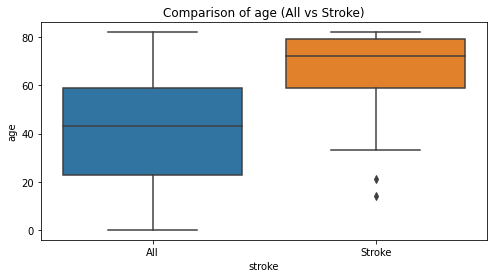

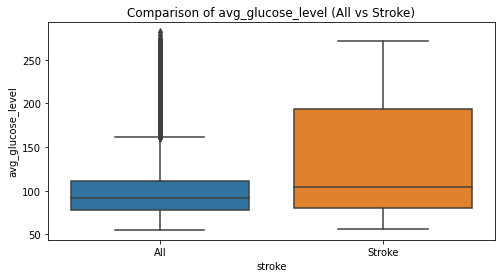

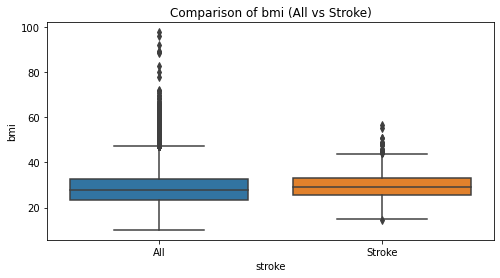

In [42]:
# Boxplot for continuous variables
for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='stroke', y=col, data=df)
    plt.title(f"Comparison of {col} (All vs Stroke)")
    plt.xticks([0, 1], ['All', 'Stroke'])
    plt.ylabel(col)
    plt.show()

***BMI Comparisson (All vs Stroke)***
- We observe from the plot that people that had a stroke tend to have a slightly higher BMI on average compared to the overall population. BMI is associated with increased health risks, one of which maybe getting a stroke. However as seen in the plot, because the difference in BMI is not extreme, although it may play an important role, it isn't  a dominant factor in this machine learning analysis.

***Average Glucose Level Comparison (All vs Stroke)***
- We observe from the plot that people who had a stroke tend to have significantly higher average glucose levels compared to the overall population. Elevated glucose levels are commonly associated with health conditions like diabetes, which is a known risk factor for stroke. The difference in glucose levels between the stroke and non-stroke groups suggests that high glucose levels could be an important indicator of stroke risk. This indicates that glucose monitoring may be very important in assessing stroke risk

## Comparision of patients without stroke vs with stroke for binary columns

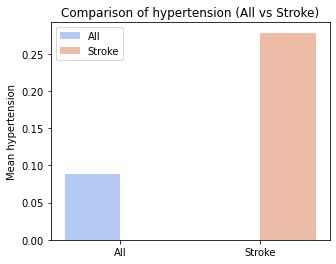

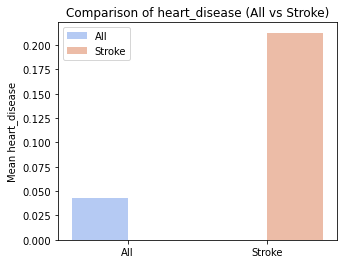

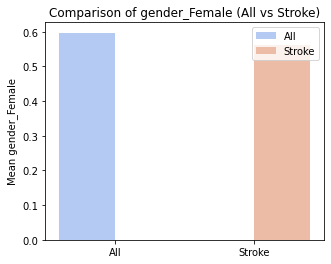

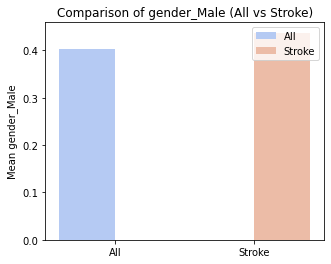

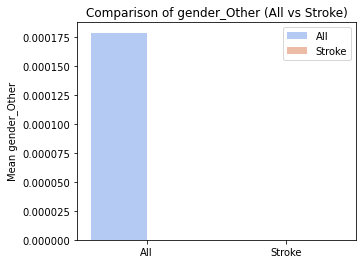

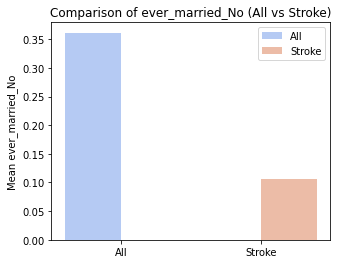

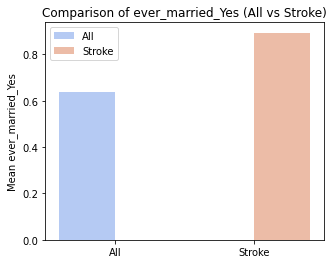

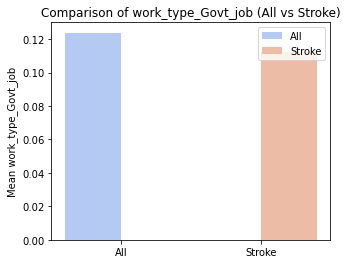

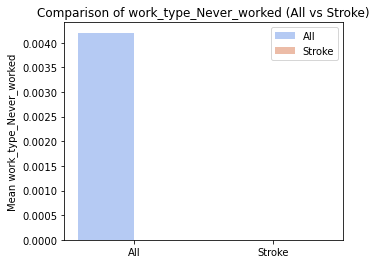

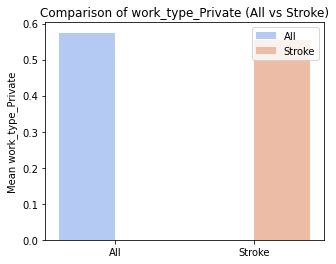

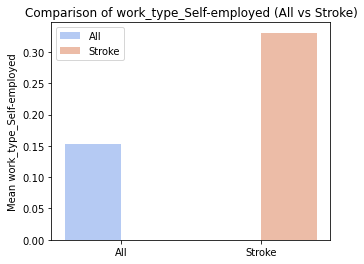

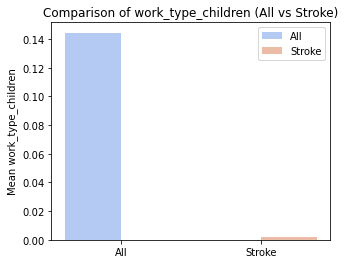

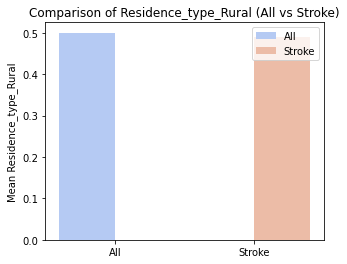

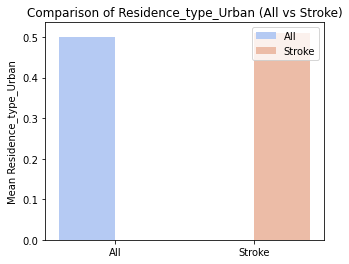

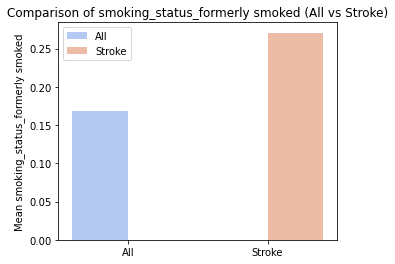

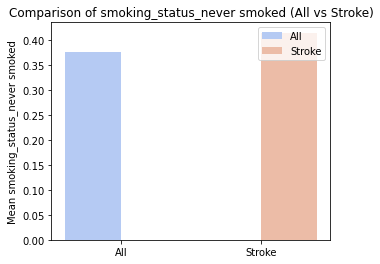

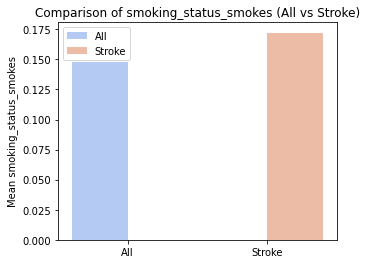

In [43]:
# Barplot for binary variables
for col in binary_cols:
    plt.figure(figsize=(5, 4))
    sns.barplot(x=['All', 'Stroke'], y=[df[col].mean(), df_stroke[col].mean()], palette='coolwarm', hue=['All', 'Stroke'])
    plt.title(f"Comparison of {col} (All vs Stroke)")
    plt.ylabel(f'Mean {col}')
    plt.show()

#TODO: Write an explanation of all the important things. 

In [44]:
df = processor.drop_not_needed_columns()

display(df.head())

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Private,work_type_Self-employed,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
id,,,,,,,,,,,,,,,,,,
52709,30.0,0,0,63.60,33.3,False,True,True,False,False,True,False,True,False,False,False,True,0
72295,75.0,1,0,215.17,48.0,True,False,False,True,False,False,True,True,False,False,True,False,0
26451,15.0,0,0,135.22,19.0,False,True,True,False,False,True,False,True,False,False,True,False,0
65210,47.0,0,0,64.89,28.2,False,True,False,True,False,False,True,False,True,False,True,False,0
69299,49.0,0,0,222.34,28.8,False,True,False,True,False,False,True,True,False,True,False,False,0


## REMOVING THE REDUNDANT/DUMMY COLUMNS
The columns are deleted because their information has been merged or transformed into new columns, which simplifies the dataset. This process eliminates redundancy and reduces the number of columns, which can make the data easier to work with and less prone to overfitting in machine learning models.

**Gender:** 
The gender_Female, gender_Male, and gender_Other columns are merged into a single gender column (0 for Female, 1 for Male). The original columns are now redundant.

**Ever Married:**
ever_married_Yes and ever_married_No are combined into a single ever_married column (1 for Yes, 0 for No), making the original columns unnecessary.

**Residence Type:**
The one-hot encoded columns for Residence_type_Rural and Residence_type_Urban are merged into residence_type (0 for Rural, 1 for Urban), so the originals are deleted.

**Work Type:**
The work_type_Self-employed column is simplified into work_type_self_employed (1 for Self-employed, 0 otherwise). The original work type columns are no longer needed.

In [45]:
df = processor.preprocess_gender()
df = processor.preprocess_ever_married()
df = processor.preprocess_residence_type()
df = processor.preprocess_work_type()

display(df.head())


,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
id,,,,,,,,,,,,,
52709,30.0,0,0,63.60,33.3,False,False,True,0,1,0,0,0
72295,75.0,1,0,215.17,48.0,False,True,False,0,0,1,0,1
26451,15.0,0,0,135.22,19.0,False,True,False,0,1,0,0,0
65210,47.0,0,0,64.89,28.2,False,True,False,0,1,1,1,1
69299,49.0,0,0,222.34,28.8,True,False,False,0,1,1,0,1


## Changing nominal data to numerical values (needed for ML)

While looking at the data , there are 5 columns that have continuous numerical values like: 'age', 'hypertension', 'heart_disease', 'avg_glucose_level' and 'bmi'. 

The other columns are only true or false statement. If we are going to use these for Machine Learning we need to transform our df to numerical values only.
While we're at it, lets change age to INT instead of FLOAT, as technically speaking you cant be 21 and half.

Transform df into only numerical values.

In [46]:
df = processor.age_to_int()
df = processor.convert_bool_to_int()
display(df.head())


,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
id,,,,,,,,,,,,,
52709,30,0,0,63.60,33.3,0,0,1,0,1,0,0,0
72295,75,1,0,215.17,48.0,0,1,0,0,0,1,0,1
26451,15,0,0,135.22,19.0,0,1,0,0,1,0,0,0
65210,47,0,0,64.89,28.2,0,1,0,0,1,1,1,1
69299,49,0,0,222.34,28.8,1,0,0,0,1,1,0,1


## Here we look at the differences per Gender

In [47]:
df_nostroke = df[df['stroke'] == 1]
df_nostroke.groupby(['gender']).mean()


,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,ever_married,residence_type,work_type_self_employed
gender,,,,,,,,,,,,
0,68.725086,0.292096,0.164948,128.032371,29.653265,0.233677,0.515464,0.134021,1.0,0.890034,0.498282,0.319588
1,68.292035,0.261062,0.274336,131.281416,30.174336,0.318584,0.283186,0.221239,1.0,0.898230,0.526549,0.345133


## Heatmap:

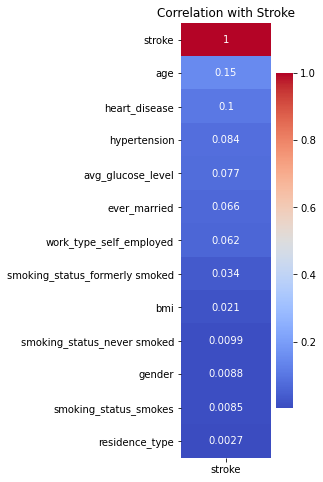

In [48]:
corr_df = df.corr()['stroke'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(2, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation with Stroke')
plt.show()

# Data cleaning

We will now look at the data (the continuous values) to see if all the data is logical and consistent

In [49]:
df_stroke = df[df['stroke'] == 1]
display(df_stroke.head())

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
id,,,,,,,,,,,,,
13491,80,0,0,259.63,31.7,0,0,1,1,1,1,0,0
3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
43424,78,0,0,78.81,19.6,0,0,0,1,0,1,0,0
36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
23260,67,0,0,89.59,25.3,0,0,0,1,1,1,1,1


### Next we will plot all columns and display boxplots for continuos values and barplots for binary values to inspect the data more closely.

In [50]:
df_nostroke = df[df['stroke'] == 1] 
stroke_count_by_gender = df_nostroke.groupby('gender').size()
display(stroke_count_by_gender)

gender
0    291
1    226
dtype: int64

# @TODO explanation why formerly smoked has a higer risk according to the data for a stroke? is it true.

# @TODO explain why gender. smoking status never smoked, smoking status smokes are getting deleted

In [51]:
columns_to_drop = [
    'gender',
    'smoking_status_never smoked', 
    'smoking_status_smokes',
    'residence_type',
]
df = processor.drop_columns(columns_to_drop)

print(df.head())

       age  hypertension  heart_disease  avg_glucose_level   bmi  \
id                                                                 
52709   30             0              0              63.60  33.3   
72295   75             1              0             215.17  48.0   
26451   15             0              0             135.22  19.0   
65210   47             0              0              64.89  28.2   
69299   49             0              0             222.34  28.8   

       smoking_status_formerly smoked  stroke  ever_married  residence_type  \
id                                                                            
52709                               0       0             0               0   
72295                               0       0             1               0   
26451                               0       0             0               0   
65210                               0       0             1               1   
69299                               1       0    

In [52]:
df_nostroke = df[df['stroke'] == 0]

There are a lot of outliers in the columns bmi & avg_glucose_levels. 
According to general medical knowlege. An assumption we could make is that people with an high BMI, average glucose level get more strokes.

To test this theory, we will find out how many people had a stroke in total, how many people with a high BMI got a stroke and how many 
people with high BMI also got a stroke. 

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
id,,,,,,,,,,,,,
13491,80,0,0,259.63,31.7,0,0,1,1,1,1,0,0
3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
43424,78,0,0,78.81,19.6,0,0,0,1,0,1,0,0
36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
23260,67,0,0,89.59,25.3,0,0,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50049,72,0,1,141.72,33.0,0,0,0,1,1,1,0,0
5095,59,0,0,79.53,29.9,0,1,0,1,1,1,1,1
4809,80,0,0,109.96,19.9,0,1,0,1,0,1,0,0


Median glucose level of stroke patients 104.12
Median glucose level of all patients 91.32
Median age of all patients 43.0
Median age of stroke patients 72.0


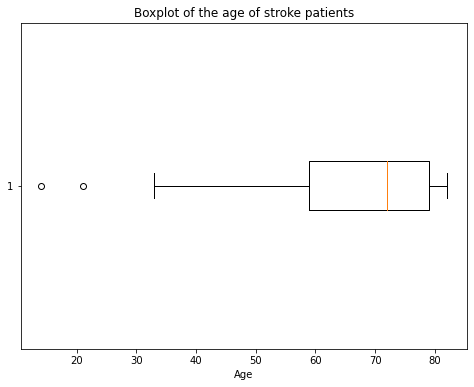

In [53]:
display(df_stroke)

print("Median glucose level of stroke patients" + str(" ") + str(df_stroke['avg_glucose_level'].median()))
print("Median glucose level of all patients" + str(" ") + str(df['avg_glucose_level'].median()))

print("Median age of all patients" + str(" ") + str(df['age'].median()))
print("Median age of stroke patients" + str(" ") + str(df_stroke['age'].median()))


plt.figure(figsize=(8, 6))
plt.boxplot(df_stroke["age"], vert=False)
plt.title("Boxplot of the age of stroke patients")
plt.xlabel("Age")
plt.show()

In [54]:
df_stroke_and_overweight = df_stroke[df_stroke['bmi'] >= 25]
display(df_stroke_and_overweight) 

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
id,,,,,,,,,,,,,
13491,80,0,0,259.63,31.7,0,0,1,1,1,1,0,0
3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
23260,67,0,0,89.59,25.3,0,0,0,1,1,1,1,1
11961,57,1,0,196.30,38.6,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20426,78,1,0,203.87,45.7,0,1,0,1,0,0,1,0
20067,74,0,0,101.67,27.9,0,1,0,1,0,0,0,0
50049,72,0,1,141.72,33.0,0,0,0,1,1,1,0,0


According to the WHO organization people with a bmi score over 25 are overweight. 
In the dataset there are 517 cases of people who had a stroke. 

When filtering the people who had a stroke and a bmi over 25, which means that they are overweight. We see that 414 people suffered from a stoke.
This strongly indicates that a majority of the patient who are overweight suffered a stroke. 

In conclusion this means that approx. 80% of overweight people also suffered from a stroke according to this dataset.

In [55]:
df_stroke_and_hypertension = df_stroke[df_stroke['hypertension'] == 1]
display(df_stroke_and_hypertension)

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
id,,,,,,,,,,,,,
3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
11961,57,1,0,196.30,38.6,0,1,0,1,0,1,0,0
6660,67,1,0,88.79,27.4,1,0,0,1,1,1,1,1
2326,67,1,0,179.12,28.1,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53156,73,1,0,77.72,31.4,0,1,0,1,1,1,0,1
36575,81,1,1,65.12,27.4,1,0,0,1,1,0,1,0
34567,81,1,0,74.02,25.0,0,1,0,1,0,1,0,1


### We will apply some basic feature engineering. We will use our medical domain knowledge to create new collumns that tell our ML model which factors indicate a higher risk to have a stroke

For Example, if a patient is over 60 (please refer to our EDA boxplot), the chance to get a stroke is higher. 
but if a patient is over 60 and also has a disease like hypertention or a heart problem, the risk of a stroke can be elevated.
This is the reason why we make new columns that show the compounding effect of these combinations. 

In [56]:
df = processor.add_age_above_60()
df = processor.add_interaction_terms()
df = processor.categorize_bmi()
df = processor.categorize_glucose()

print(df[['age_above_60', 'age_above_60_hypertension', 'age_above_60_heart_disease', 'hypertension_former_smoker', 'bmi_category', 'glucose_category']].head())
display(df)


       age_above_60  age_above_60_hypertension  age_above_60_heart_disease  \
id                                                                           
52709             0                          0                           0   
72295             1                          1                           0   
26451             0                          0                           0   
65210             0                          0                           0   
69299             0                          0                           0   

       hypertension_former_smoker bmi_category glucose_category  
id                                                               
52709                           0        obese           normal  
72295                           0        obese         diabetic  
26451                           0       normal           normal  
65210                           0   overweight           normal  
69299                           0   overweight         di

,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,stroke,ever_married,residence_type,work_type_self_employed,age_above_60,age_above_60_hypertension,age_above_60_heart_disease,hypertension_former_smoker,bmi_category,glucose_category
id,,,,,,,,,,,,,,,,
52709,30,0,0,63.60,33.3,0,0,0,0,0,0,0,0,0,obese,normal
72295,75,1,0,215.17,48.0,0,0,1,0,1,1,1,0,0,obese,diabetic
26451,15,0,0,135.22,19.0,0,0,0,0,0,0,0,0,0,normal,normal
65210,47,0,0,64.89,28.2,0,0,1,1,1,0,0,0,0,overweight,normal
69299,49,0,0,222.34,28.8,1,0,1,0,1,0,0,0,0,overweight,diabetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71911,9,0,0,109.80,14.5,0,0,0,0,0,0,0,0,0,underweight,normal
19648,47,0,0,88.61,30.8,0,0,1,1,0,0,0,0,0,obese,normal
35550,3,0,0,89.68,16.2,0,0,0,0,0,0,0,0,0,underweight,normal


In [57]:
df = processor.encode_categories()
df = processor.drop_categorical_columns()

In [58]:
X = df.drop(columns=['stroke']) 
y = df['stroke']  

# Random Undersampling for balance
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)

# cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(clf, X, y, cv=kfold, scoring='f1')

y_pred = clf.predict(X_test)

# confusion matrix
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.64      0.71      0.67       102
           1       0.68      0.61      0.64       105

    accuracy                           0.66       207
   macro avg       0.66      0.66      0.66       207
weighted avg       0.66      0.66      0.66       207



In [59]:

# Random Undersampling for balance
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 2: Train your DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Load the new test data
new_data = pd.read_csv('test.csv') 

# PREPROCESSING
def clean_data(dataframe, columns_to_drop, reference_columns):
    processor = DataPreprocessor(dataframe)
    cleaned_data = processor.preprocess(columns_to_drop, reference_columns)
    return cleaned_data

new_data = pd.read_csv('test.csv')  
columns_to_drop = ['gender', 'smoking_status_never smoked', 'smoking_status_smokes']
reference_columns = X.columns  
X_new = clean_data(new_data, columns_to_drop, reference_columns)


# Step 4: Make predictions
y_new_pred = clf.predict(X_new)

# Optional: If the true labels are available in the new test data
if 'stroke' in new_data.columns:
    y_true = new_data['stroke']
    print(classification_report(y_true, y_new_pred))

# Output predictions
print("Predictions on the new test data:", y_new_pred)


Predictions on the new test data: [0 0 0 ... 0 0 0]


In [60]:

# Save the model
joblib.dump(clf, 'decision_tree_model.pkl')

# Load the model later when needed
loaded_model = joblib.load('decision_tree_model.pkl')


In [61]:
# Make predictions using the preprocessed new data
predictions = loaded_model.predict(X_new)

# Display the predictions
print("Predictions on the new data:")

#  # Save predictions to a CSV file
output_df = pd.DataFrame(predictions, columns=['Predicted_Target'])
# output_df.to_csv('predictions.csv', index=False)



Predictions on the new data:


## Decision Tree

*Describe how this model works.*

A decision tree is a machine learning model that helps make decisions by splitting the data into smaller groups based on features in the data. Each questions (or decision) about the data leads to a branch and eventually a final decision is made. The process starts at the root node, where the models chooses the most important feature to split the data first. As the data gets split, additional questions are asked "Is the person with avg_glucose > 215.17?" and then in the last stage (the leaf nodes) a decision (=prediction) is made "Yes, the person will get a stroke.".

The tree decides which feature provides the best split using measures like Gini or Entropy. Through the usage of these both methods the uncertainty of our predictions should be reduced and the groups of data will become more homegenous.


*Describe the criteria on the basis of which the splits in the decision tree can be made. *

There are different criteria, based on which the data can be split - entropy, gini impurity, MSE, MAE, poisson deviance, huber loss, cross-entropy, friedman MSE, laplacian. As we are facing a classification problem and are dealing with categorical labels, we will be using the standart entropy and gini impurity measures to split the data.

As we are dealing with a binary classification problem (no strok=0, stroke=1) and the outcome is categorical (as we are predicting a class label stroke= 0 or 1 based on the other aformentioned features), we will firstly check which hyperparameters are best suited for our dataset. 

To find out which hyperparameter values are best suited and determine the best combination for our decision tree we will be using the GridSearchCV to systematicly test a wide range of hyperparameter values and determine the best combinations for our model.

In [62]:
from sklearn.model_selection import GridSearchCV

# max depth -> controlls the depth of the tree to avoid overfitting.
# We will try with a shallow tree(5), a slightly deeper one(10) and a relatively deep tree (15)
# min_samples_split -> controls the minimum number of samples needed to split a node
# Higher values (10, 20) prevent the tree from growing too deep.
# min_samples_leaf -> controls the minimum number of samples in a leaf node
# Larger leaf sizes (5, 10) promote generalization and reduce overfitting
# criterion -> the function used to measure the quality of a split (Gini or Entropy)
# gini is faster, while entropy can get better results for complex data.
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=kfold, scoring='f1')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f'Best hyperparameters values are: {best_params}')

Best hyperparameters values are: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}


*Explain what 'pruning' is and describe what forms of it have been applied.*
*Explain the relationship between 'pruning' and 'underfitting'.**

Prunning is the process of removing unnecessary branches/nodes from the decision tree to make it simpler and prevent the risk of overfitting the data. There are 2 main types of prooning, pre-prunning this is where we adjusted the max_depth, min_samples_split and min_samples_leaf. In doing so we prevented our tree from growing too large and capturing unnecessary details form the training data. Underfitting on the other hand happens, when the model is too simple to capture specific patterns in the data. Meaning - that if we prune too much our decision tree, by setting for example a overly strict min_samples_split of 50, the tree might become too shallow and fail to learn important relationships, which would lead to underfitting. 


In [63]:

best_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

best_clf.fit(X_train, y_train)

y_pred_best = best_clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.68      0.83      0.75       102
           1       0.79      0.62      0.70       105

    accuracy                           0.72       207
   macro avg       0.74      0.73      0.72       207
weighted avg       0.74      0.72      0.72       207



Logistical Regression 

Logistic regression is a statistical model that is used to make a binary decision. This means that it helps to distinguish between two possible outcomes, e.g. in our case, it is about predicting whether a person will suffer a stroke (1) or not (0) based on certain information (e.g. age, glucose level, etc).
#### **How does the model work?**

**Inputs:** We have several characteristics (also called features), such as age, glucose level and BMI. These values are numbers and are given as inputs to the model.

**Calculating the weighting:** Each characteristic has a certain importance, which is determined by so-called "weights". The model multiplies each characteristic by a weight and adds everything together. The result is a number that roughly shows how likely it is that the result is 1 or 0.

**Sigmoid function:** This number is then converted into a probability between 0 and 1 using the logistic function (also known as the sigmoid function). This function ensures that all values fall into the range 0 to 1, which corresponds to a probability.

$$ \text{Sigmoid-Function} = \frac{1}{1 + e^{-z}} $$

*z = the sum of the weighted characteristics*

#### **What is the loss function?**

The loss function measures how well or poorly the model works. The smaller the loss, the better the model works. In logistic regression, we use a special loss function called "Log-Loss".
E.g. if the model predicts for a person that the probability of a stroke is 90%, but the person does not have a stroke, this is a bad prediction and the **loss is high**.
If the model predicts 90% probability for a person and the person actually has a stroke, then the **loss is small** because the prediction was good.
The goal is to minimize the loss for the entire model.

$$ \text{Log-Loss} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] $$

\( y_i \) *represents the actual labels (either 0 or 1).* 

\( p_i \) *the predicted probability for class 1.*


#### **What is gradient descent in this context?**

Gradient Descent is the method we use to find the best weights for our logistic regression model. The goal is to **minimize the loss function (log-loss)**, which measures how far off the model’s predictions are from the actual values.

**Simple calculation example:**
Let’s say we are predicting whether someone has a stroke based on just age. We start with a random weight, say $\theta = 0.5$, for age.

For one data point, say a 60-year-old person, we calculate $z$, the weighted sum of the input:
$$
z = \theta \times \text{age} = 0.5 \times 60 = 30
$$

Then we apply the **sigmoid function** to get the probability (prediction):

$$
h_\theta(x) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-30}} \approx 1
$$

So, our model predicts a probability close to 1 (very likely stroke).

**Next steps:**

1. **Calculating the loss:**
If the actual outcome is $y = 0$ (no stroke), we calculate the loss using the log-loss function:

$$
J(\theta) = -[y \log(h_\theta(x)) + (1 - y) \log(1 - h_\theta(x))]
$$

Since $y = 0$, the loss becomes very large because the model predicted the wrong outcome:

$$
J(\theta) \approx -[0 \times \log(1) + (1 - 0) \log(0)] = \infty
$$

2. **Calculating the gradient:**
The gradient shows how much to adjust $\theta$. The gradient for $\theta$ is:

$$
\frac{\partial J(\theta)}{\partial \theta} = (h_\theta(x) - y) \times \text{age}
$$

which equals:

$$
\frac{\partial J(\theta)}{\partial \theta} = (1 - 0) \times 60 = 60
$$

2. **Updating the weights:**
We adjust $\theta$ using the gradient and a learning rate $\alpha$ (say $\alpha = 0.01$):

$$
\theta := \theta - \alpha \times \frac{\partial J(\theta)}{\partial \theta}
$$

So, the new value of $\theta$ becomes:

$$
\theta := 0.5 - 0.01 \times 60 = -0.1
$$

#### **What are the forms of regularization that apply to this model?**

There are two main forms of regularization that apply to logistic regression:

1. **L1 Regularization ("Lasso")**:
- This type of regularization adds a penalty to the model based on the absolute values of the coefficients. It tends to push some coefficients to zero, effectively removing less important features from the model. This helps with feature selection.

- The penalty term for L1 regularization is:

$$ \text{Penalty} = \lambda \sum |\theta_j| $$

2. **L2 Regularization ("Ridge")**:
- L2 regularization adds a penalty proportional to the square of the coefficients. Unlike L1, it doesn’t eliminate features but instead reduces the magnitude of all the coefficients, making the model less sensitive to small variations in the data.

- The penalty term for L2 regularization is:

$$ \text{Penalty} = \frac{\lambda}{2} \sum \theta_j^2 $$

Both of these methods help reduce overfitting by preventing the model from becoming too complex.

#### **How does regularization relate to overfitting?**

Overfitting happens when a model learns not just the meaningful relationships between the features and the target but also the noise (e.g. errors, outliers,..) in the training data. Regularization helps prevent this by penalizing large coefficients.

- **L1 regularization** eliminates unimportant features by pushing their coefficients to zero, reducing the complexity of the model.
- **L2 regularization** keeps all the features but reduces the size of the coefficients, making the model simpler and less prone to fitting the noise in the training data.

Simply put, regularization helps the model perform better on new, unseen data.

#### **At which hyperparameters does the model give the best results?**

The main hyperparameter for regularization is *C*. It controls how strong the regularization is. A **larger *C* value means less regularization**, so the model can fit the training data more closely. A **smaller *C* value increases regularization**, shrinking the coefficients and helping prevent overfitting.

To find the best C-value, you can either use cross-validation tools like *GridSearchCV* to automatically find the optimal value or manually experiment with different values like *C= 0.1, 1.0, 10, 100,..* and see which one gives the best results for your model.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Adding regularization: L2 & C=1.0 are the defaults
lr = LogisticRegression(penalty='l2',C=1.0, class_weight='balanced') # "class weighting" technique for imbalanced data
lr.fit(X_train, y_train)

#Making predictions
y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.75      0.76       102
           1       0.77      0.78      0.77       105

    accuracy                           0.77       207
   macro avg       0.77      0.77      0.77       207
weighted avg       0.77      0.77      0.77       207



**Ensembles (Random Forest, Gradient Boosted Boosted Decistion Trees and XGboost)**

- *Describe the operation of the 3 ensembles mentioned. Use the terms "bagging (bootstrap aggregation)" and "boosting".* 
	- *Explain which ensembles need a relatively large amount of training time and which ones need little time. Use at least the terms "sequential" and "parallel”.*
    
- *Determine at which hyperparameters each ensemble gives the best results on the chosen metric.*

**Random Forest**

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Option 1: Apply Undersampling (comment out if using SMOTE)
undersampler = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

# Option 2: Apply SMOTE (Oversampling)
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the resampled training data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test set with the default threshold (0.5)
y_pred_default = rf_model.predict(X_test)

# Evaluate the model with the default threshold
print("Random Forest Classification Report with Default Threshold (0.5):")
print(classification_report(y_test, y_pred_default, zero_division=1))
print("Accuracy:", accuracy_score(y_test, y_pred_default))

# Get the predicted probabilities for the positive class (stroke)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Set a custom threshold (try values between 0.3 and 0.4 to start)
threshold = 0.9
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluate with the custom threshold
print(f"\nClassification Report with Custom Threshold {threshold}:")
print(classification_report(y_test, y_pred_custom, zero_division=1))
print("Accuracy with Custom Threshold:", accuracy_score(y_test, y_pred_custom))


Random Forest Classification Report with Default Threshold (0.5):
              precision    recall  f1-score   support

           0       1.00      0.73      0.85      6607
           1       0.04      0.76      0.08       102

    accuracy                           0.73      6709
   macro avg       0.52      0.75      0.46      6709
weighted avg       0.98      0.73      0.83      6709

Accuracy: 0.7349828588463259

Classification Report with Custom Threshold 0.9:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      6607
           1       0.05      0.10      0.07       102

    accuracy                           0.96      6709
   macro avg       0.52      0.53      0.52      6709
weighted avg       0.97      0.96      0.96      6709

Accuracy with Custom Threshold: 0.9573706960798927
